# Adult Income

## Importy

In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sbn
import datetime as dttm
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import GridSearchCV
from IPython.display import display
from tqdm import tqdm
pd.set_option('display.max_colwidth', None)

adult_income = fetch_ucirepo(id=2)

## Dane

In [108]:
income_data = pd.DataFrame(adult_income.data.features)
income_data['target'] = pd.DataFrame(adult_income.data.targets)['income']

display(adult_income.metadata)
display(adult_income.variables)

display(income_data.head(10))
display(income_data.dtypes)
display(income_data.shape)
display(income_data.isna().sum())
print(f"Udział brakujących danych w kolumnie 'workclass': {round(income_data['workclass'].isna().mean()*100,2)}%")
print(f"Udział brakujących danych w kolumnie 'occupation': {round(income_data['occupation'].isna().mean()*100,2)}%")
print(f"Udział brakujących danych w kolumnie 'native-country': {round(income_data['native-country'].isna().mean()*100,2)}%")

income_data = income_data.fillna('Missing') # mało się da zrobić poza tym
income_data['target'] = np.where(income_data['target'].str.endswith('.'),income_data['target'].str.partition(sep='.')[0],income_data['target'])

train_data, test_data = train_test_split(income_data, test_size=0.2, random_state=67, stratify=income_data['target'])
train_data = pd.DataFrame(train_data); test_data = pd.DataFrame(test_data)

{'uci_id': 2,
 'name': 'Adult',
 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult',
 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv',
 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ',
 'area': 'Social Science',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 48842,
 'num_features': 14,
 'feature_types': ['Categorical', 'Integer'],
 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'],
 'target_col': ['income'],
 'index_col': None,
 'has_missing_values': 'yes',
 'missing_values_symbol': 'NaN',
 'year_of_dataset_creation': 1996,
 'last_updated': 'Tue Sep 24 2024',
 'dataset_doi': '10.24432/C5XW20',
 'creators': ['Barry Becker', 'Ronny Kohavi'],
 'intro_paper': None,
 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was ex

,name,role,type,demographic,description,units,missing_values
0,age,Feature,Integer,Age,N/A,None,no
1,workclass,Feature,Categorical,Income,"Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked.",None,yes
2,fnlwgt,Feature,Integer,NaN,NaN,None,no
3,education,Feature,Categorical,Education Level,"Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool.",None,no
4,education-num,Feature,Integer,Education Level,NaN,None,no
5,marital-status,Feature,Categorical,Other,"Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse.",None,no
6,occupation,Feature,Categorical,Other,"Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces.",None,yes
7,relationship,Feature,Categorical,Other,"Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried.",None,no
8,race,Feature,Categorical,Race,"White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other, Black.",None,no
9,sex,Feature,Binary,Sex,"Female, Male.",None,no


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,target
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
8,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K
9,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K


age               int64
workclass           str
fnlwgt            int64
education           str
education-num     int64
marital-status      str
occupation          str
relationship        str
race                str
sex                 str
capital-gain      int64
capital-loss      int64
hours-per-week    int64
native-country      str
target              str
dtype: object

(48842, 15)

age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
target              0
dtype: int64

Udział brakujących danych w kolumnie 'workclass': 1.97%
Udział brakujących danych w kolumnie 'occupation': 1.98%
Udział brakujących danych w kolumnie 'native-country': 0.56%


## EDA

age
36    1038
31    1025
35    1009
33    1002
23     996
      ... 
76      42
77      33
80      25
78      20
79      16
Name: count, Length: 64, dtype: int64

workclass
Private             25636
Self-emp-not-inc     2732
Local-gov            2376
State-gov            1468
?                    1256
Self-emp-inc         1185
Federal-gov          1057
Missing               652
Name: count, dtype: int64

fnlwgt
203488    15
120277    14
125892    14
113364    14
127651    14
          ..
227146     1
224964     1
138580     1
284211     1
148998     1
Name: count, Length: 23182, dtype: int64

education
HS-grad         11878
Some-college     8198
Bachelors        5973
Masters          1921
Assoc-voc        1561
11th             1340
Assoc-acdm       1178
10th             1036
7th-8th           695
9th               574
Prof-school       535
12th              503
Doctorate         408
5th-6th           373
1st-4th           189
Name: count, dtype: int64

education-num
9     11878
10     8198
13     5973
14     1921
11     1561
7      1340
12     1178
6      1036
4       695
5       574
15      535
8       503
16      408
3       373
2       189
Name: count, dtype: int64

...

capital-gain
0        33622
15024      393
7688       302
7298       280
3103       124
         ...  
18481        1
6097         1
3432         1
1639         1
1264         1
Name: count, Length: 112, dtype: int64

capital-loss
0       34971
1902      243
1977      190
1887      185
1485       59
1848       53
1740       47
1590       47
1876       46
1602       43
1672       42
1564       38
1741       35
1980       28
1669       28
1719       26
1974       25
1579       24
1504       22
1408       21
1721       20
1628       17
1762       16
1573       11
1340       10
1617       10
625        10
1726        8
1380        8
1651        8
1092        8
213         5
1258        5
1668        5
1594        5
1825        4
653         4
880         4
323         4
1844        3
1735        3
1648        2
1755        2
419         2
810         2
1138        2
974         2
1816        2
1870        1
1510        1
1539        1
1411        1
1429        1
1911        1
1944        1
Name: count, dtype: int64

hours-per-week
40    17463
50     3186
45     2063
60     1573
35     1457
      ...  
74        2
89        2
79        1
87        1
69        1
Name: count, Length: 78, dtype: int64

native-country
United-States         33000
Mexico                  714
?                       442
Philippines             218
Missing                 205
Germany                 168
Puerto-Rico             142
Canada                  138
El-Salvador             115
India                   106
Cuba                    106
England                  92
China                    91
Jamaica                  85
Italy                    82
Dominican-Republic       82
South                    79
Japan                    72
Columbia                 68
Guatemala                67
Poland                   65
Vietnam                  63
Portugal                 55
Haiti                    54
Taiwan                   53
Name: count, dtype: int64

target
<=50K    27843
>50K      8519
Name: count, dtype: int64

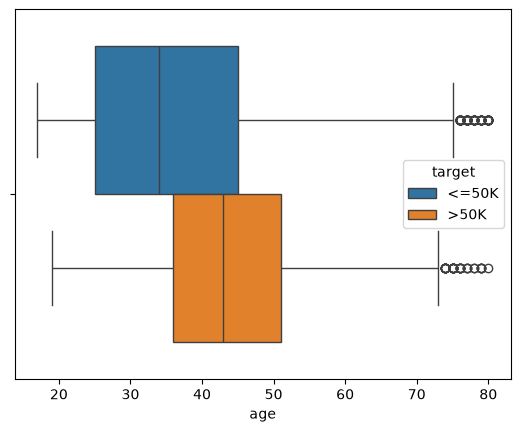

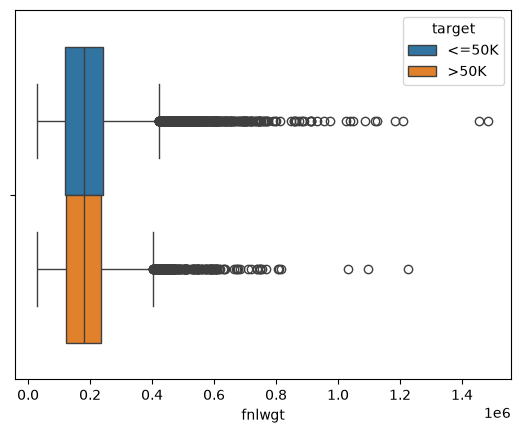

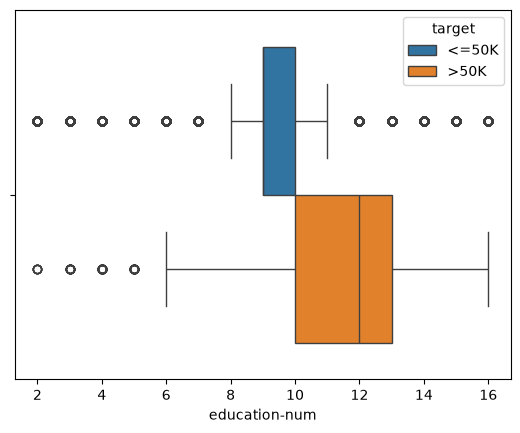

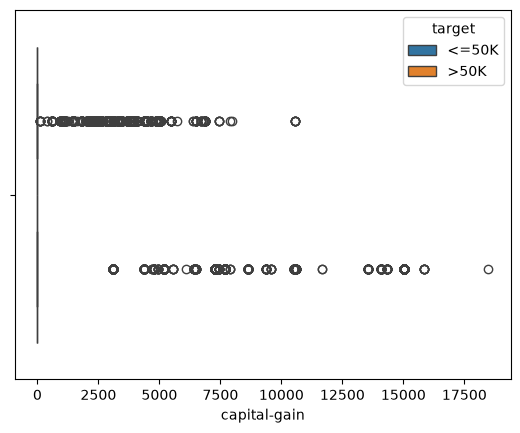

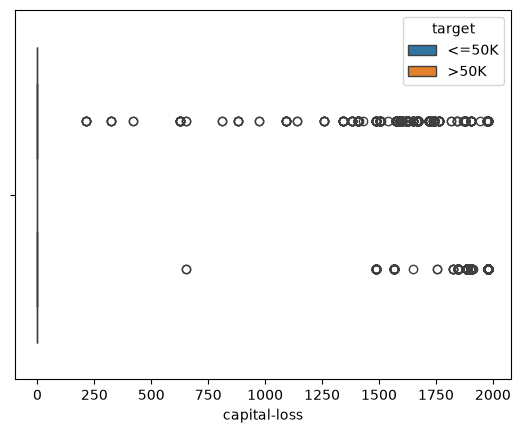

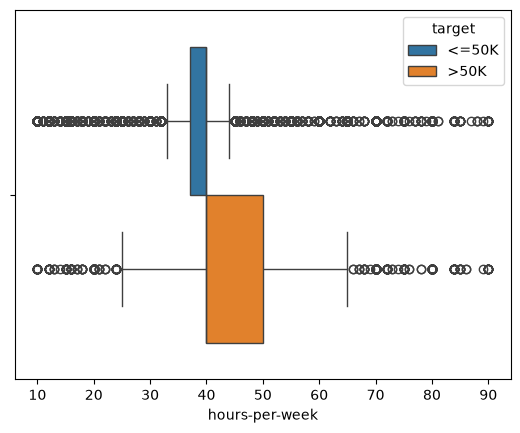

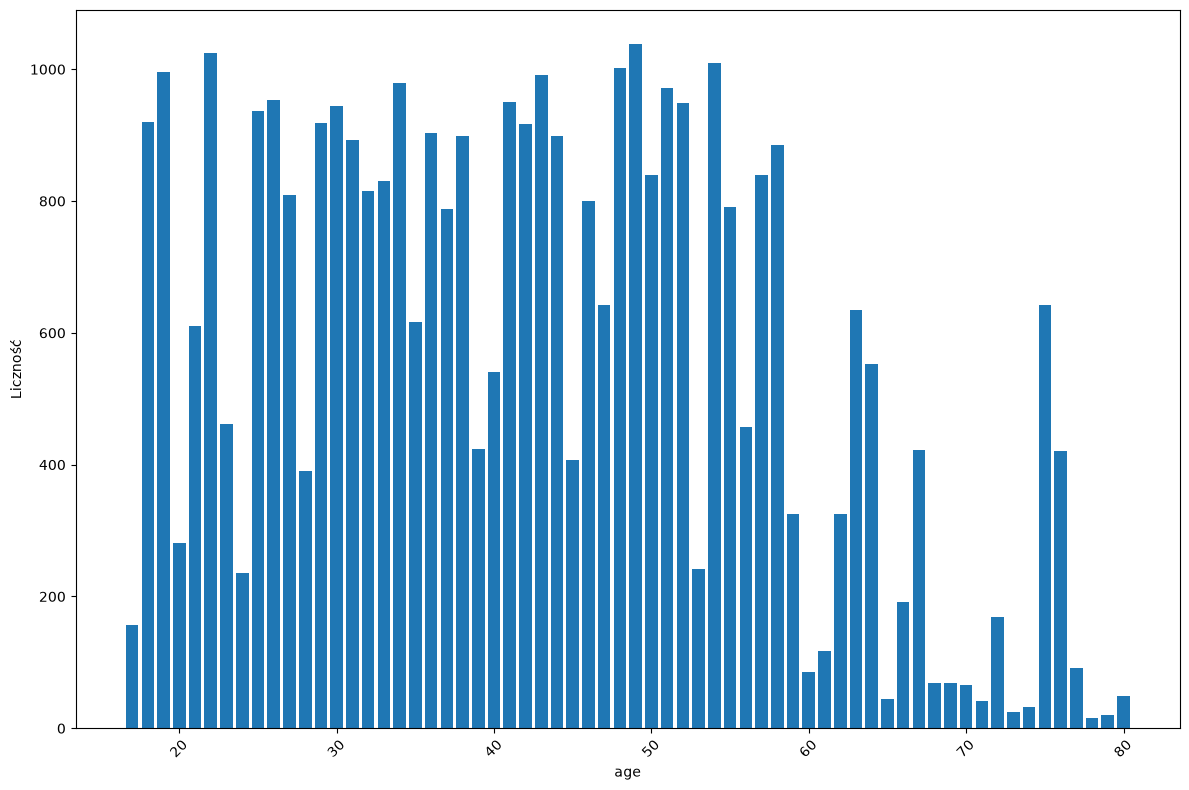

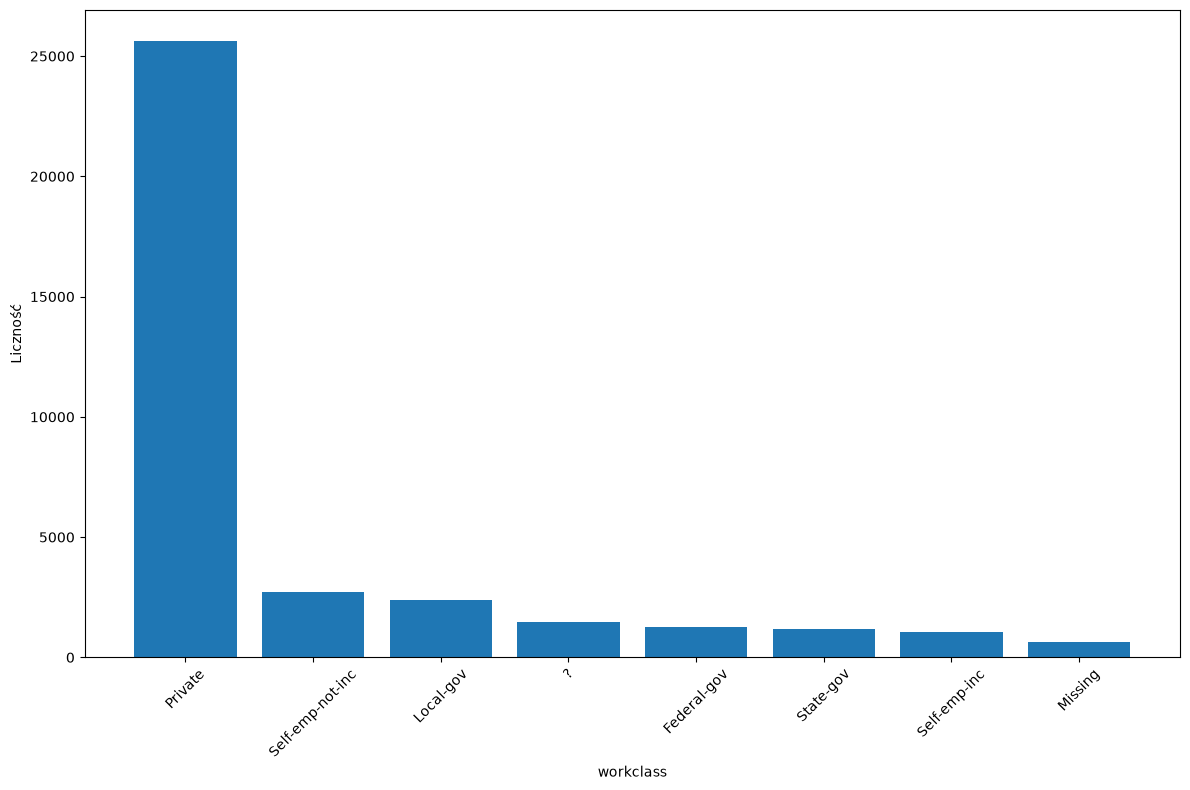

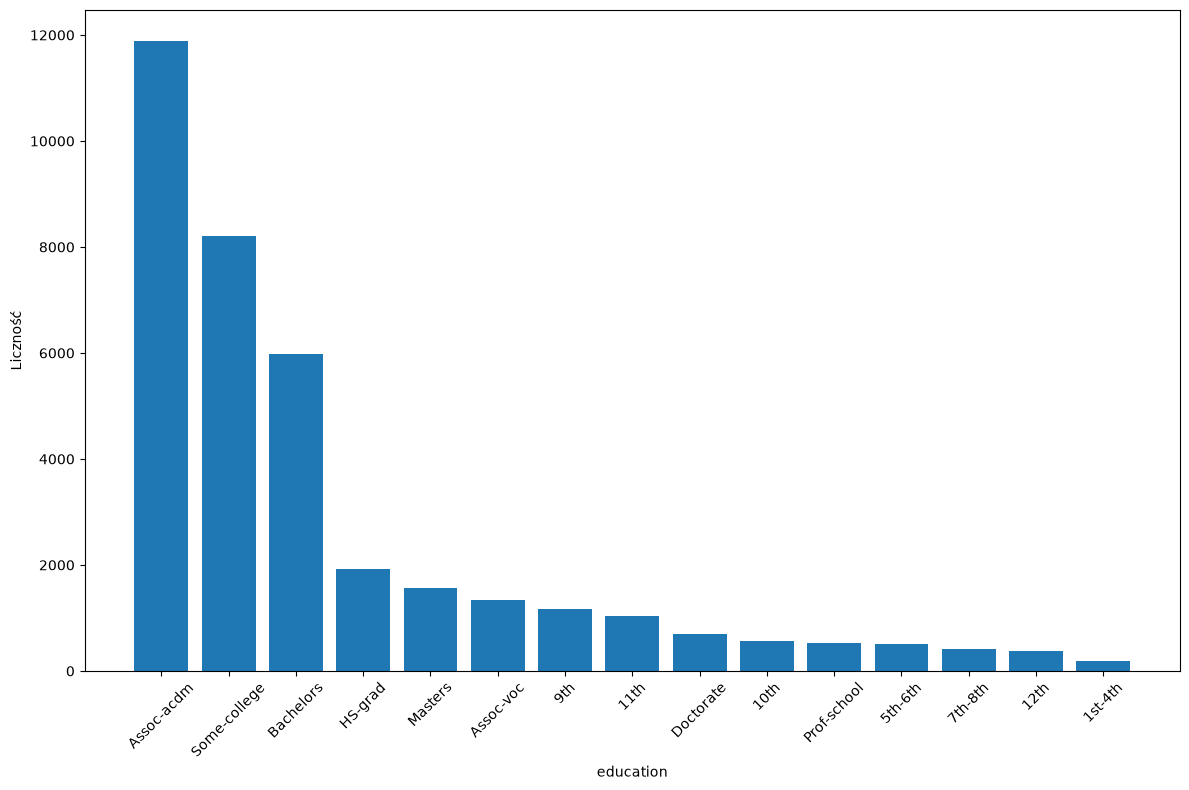

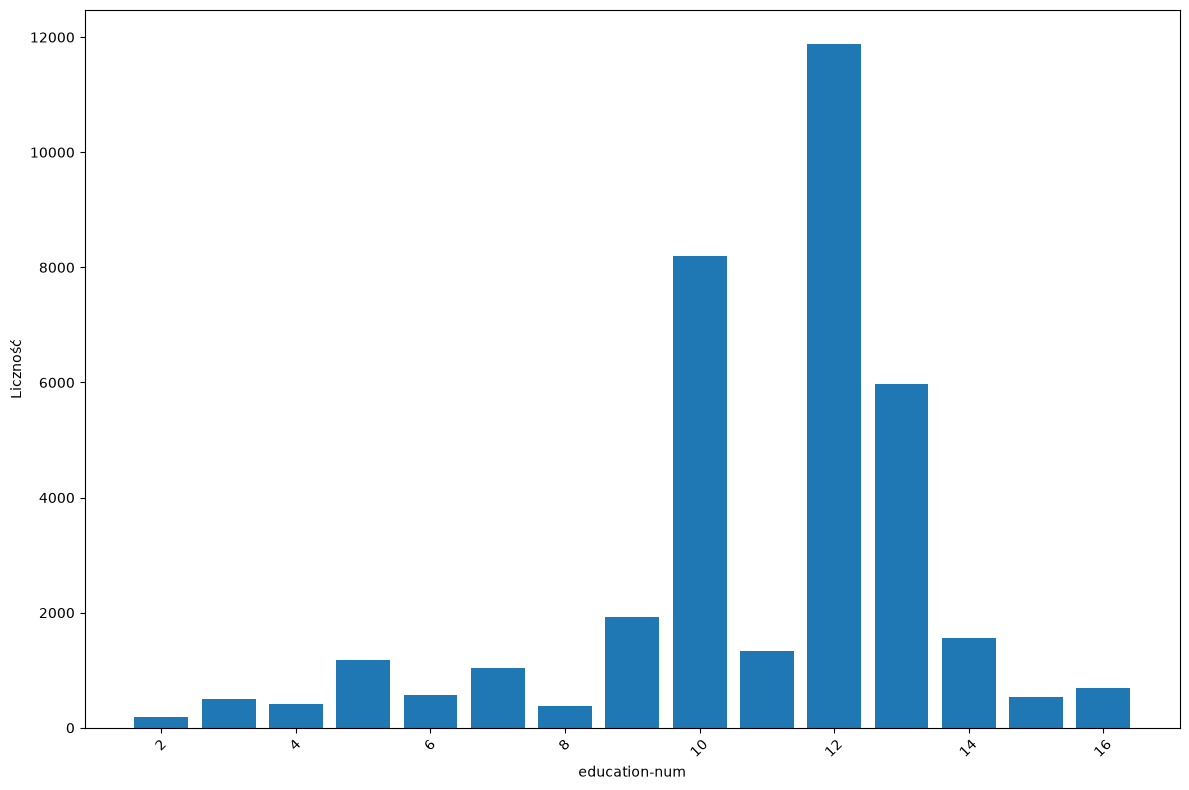

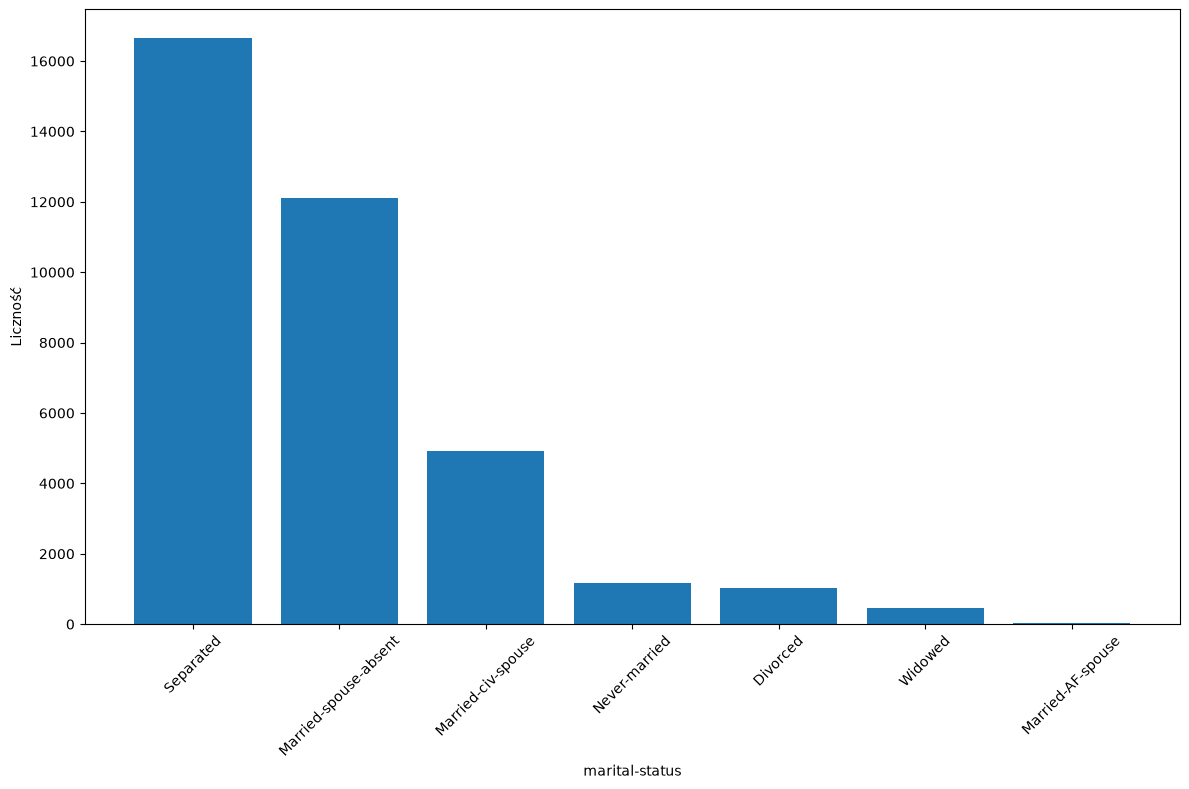

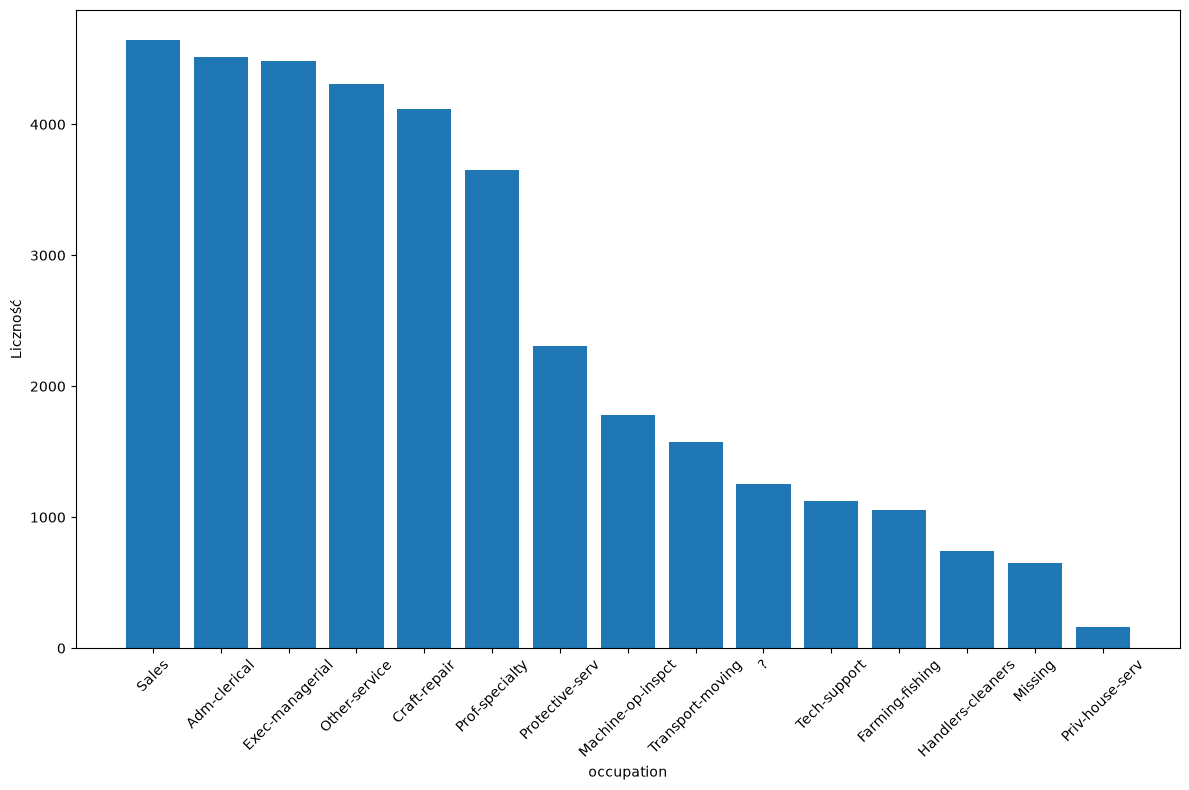

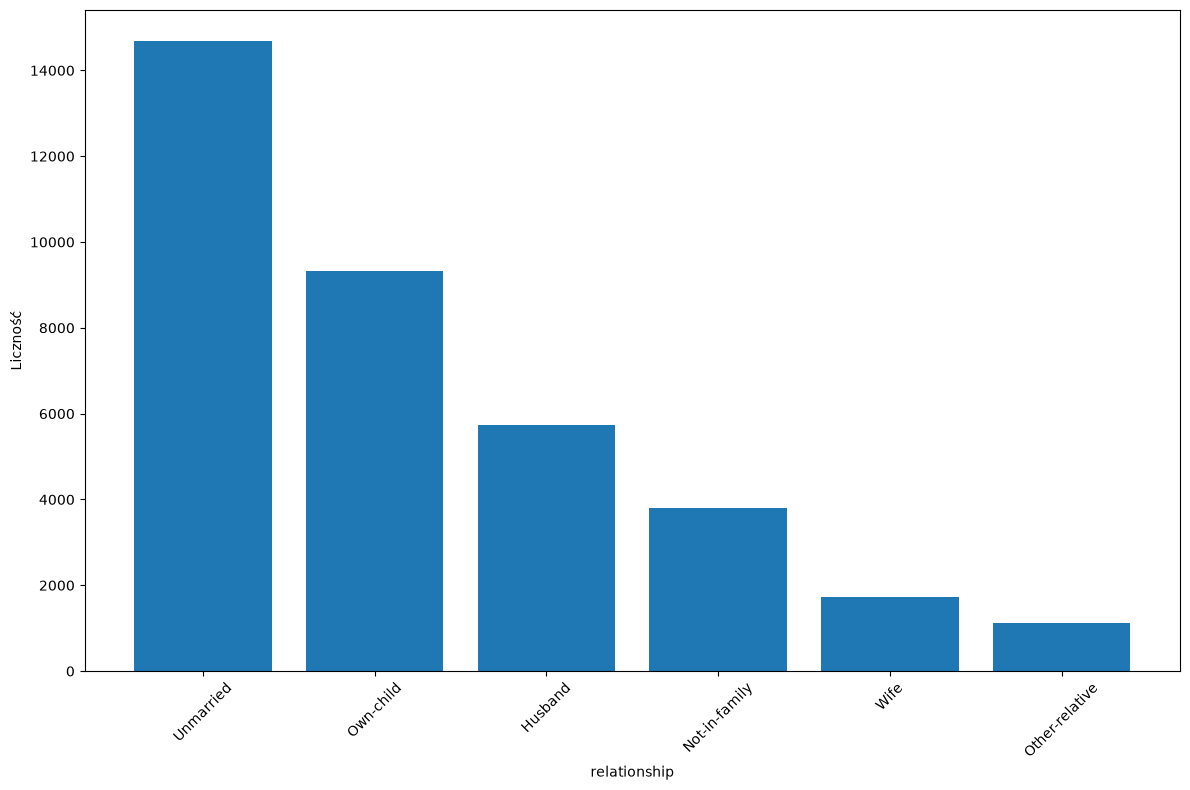

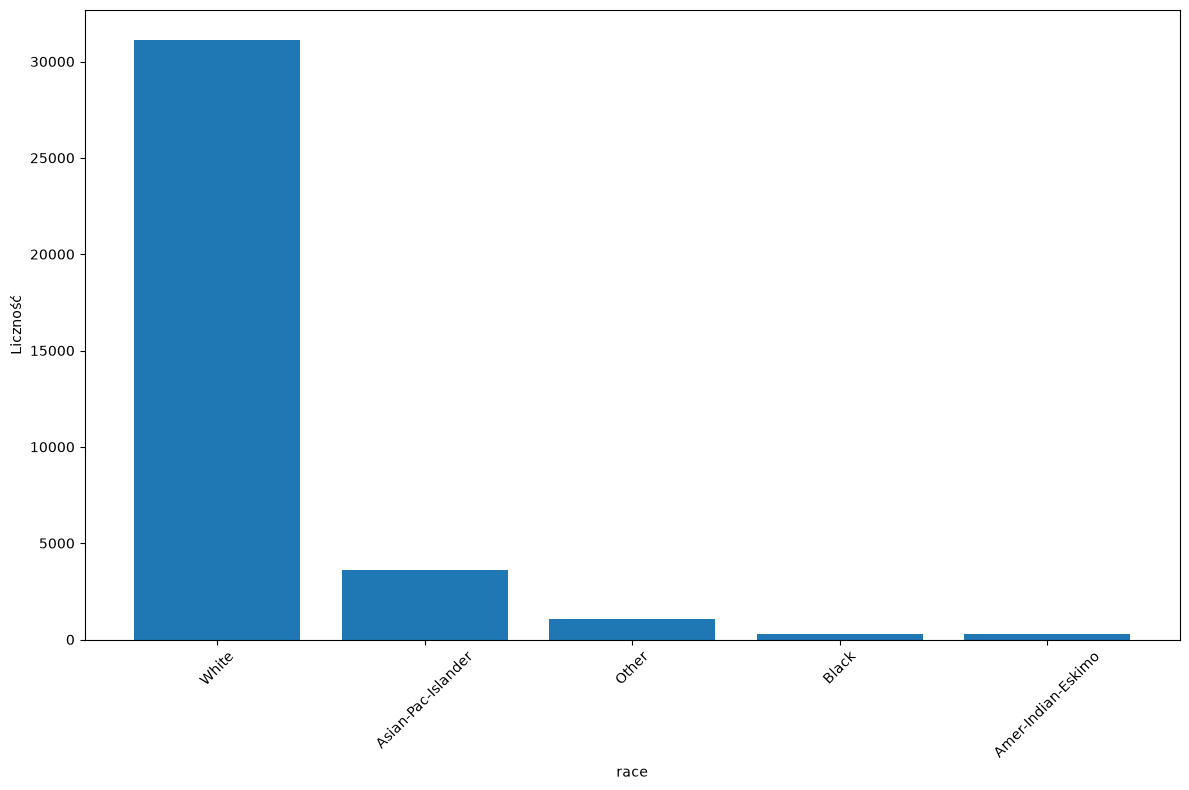

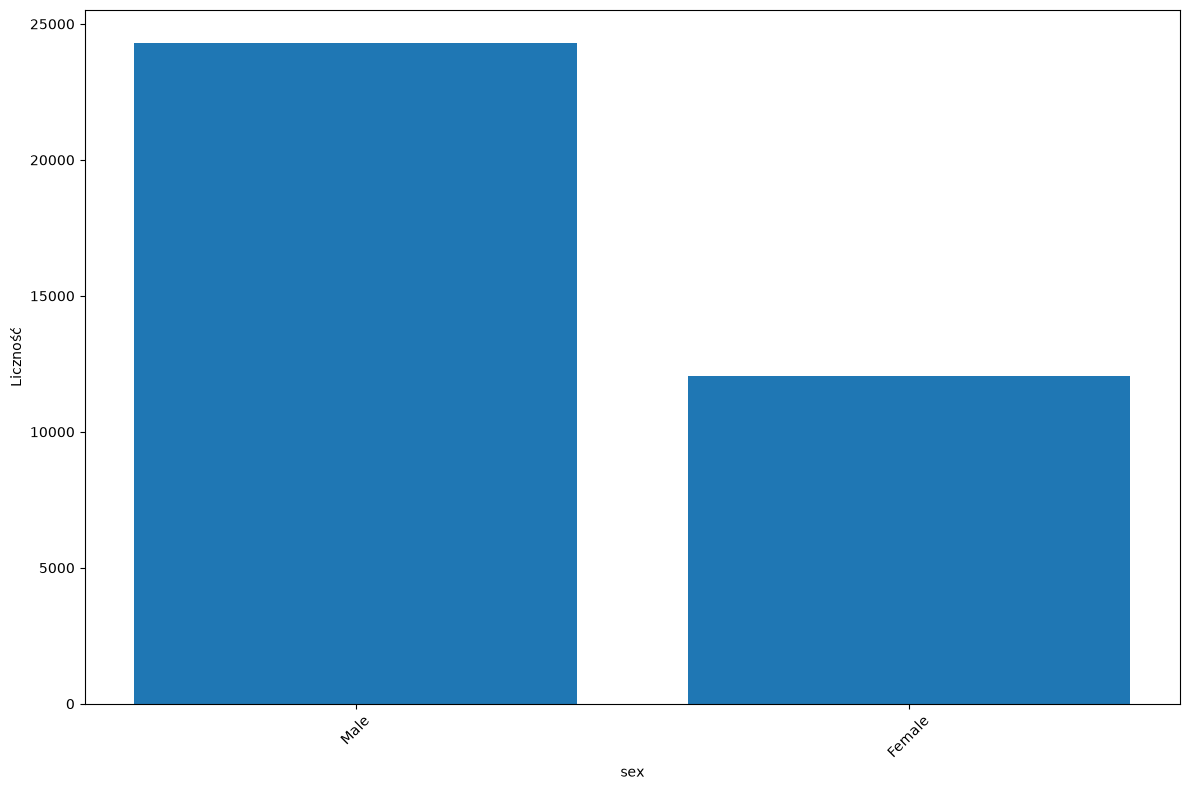

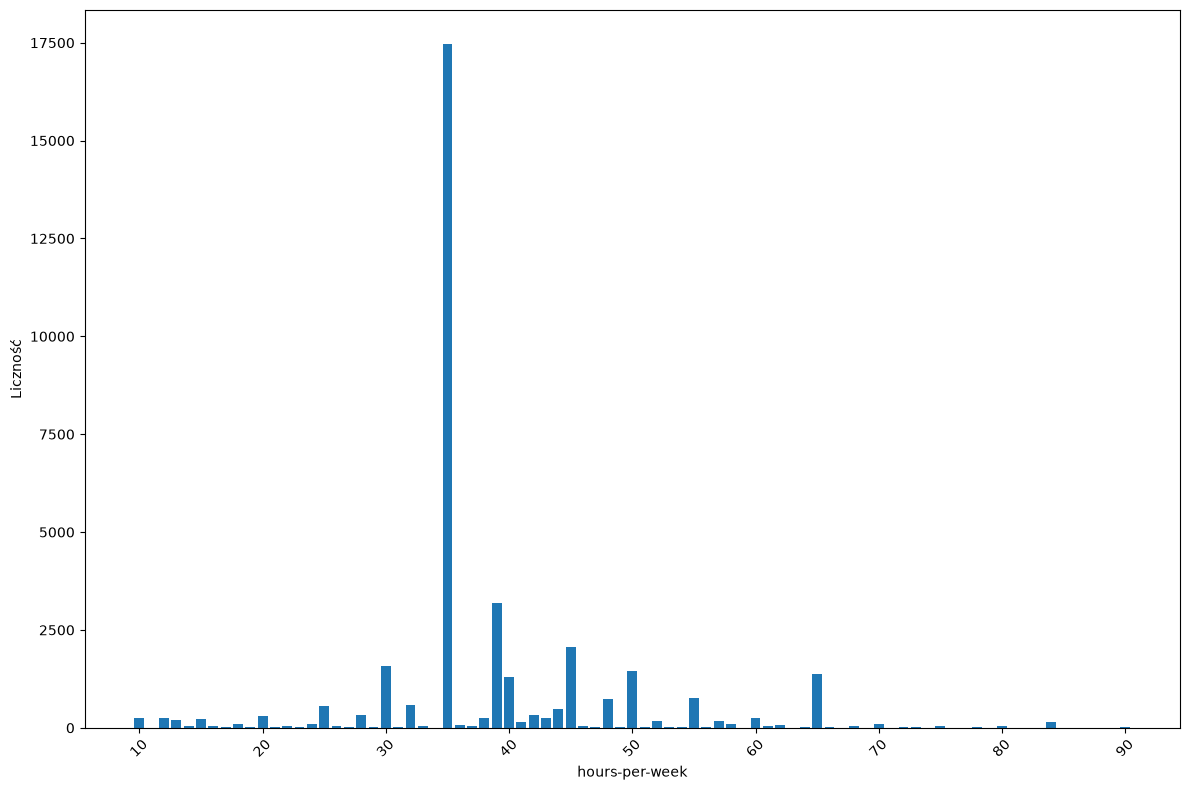

Liczba osób które będziemy dalej rozważać: 36362


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
age,1.000000,-0.071132,0.028765,0.111165,0.038688,0.113353
fnlwgt,-0.071132,1.000000,-0.041847,0.000683,-0.010329,-0.016982
education-num,0.028765,-0.041847,1.000000,0.140284,0.082064,0.149013
capital-gain,0.111165,0.000683,0.140284,1.000000,-0.046793,0.090503
capital-loss,0.038688,-0.010329,0.082064,-0.046793,1.000000,0.053023
hours-per-week,0.113353,-0.016982,0.149013,0.090503,0.053023,1.000000


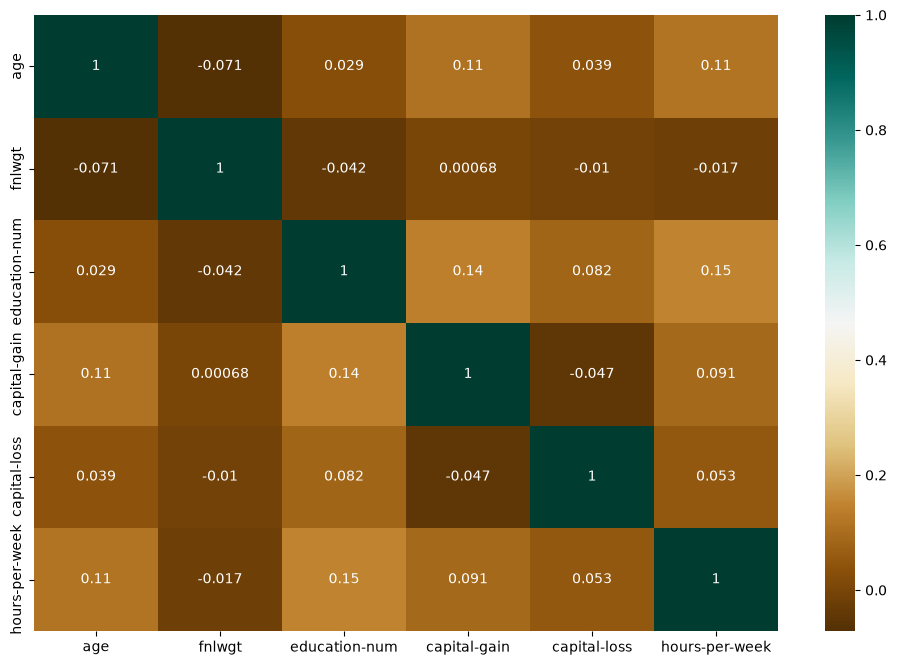

In [ ]:
train_data = train_data.drop_duplicates()
train_data = train_data[train_data['fnlwgt'] >= 30000] # dropping the biggest outliers

for col in train_data.columns:
    display(train_data[col].value_counts())


num_cols = train_data.select_dtypes(include=np.number).columns
for col in num_cols:
    sbn.boxplot(x=train_data[col], hue=train_data['target'])
    plt.show() # big positive correlation of >50k income with age, education-num and hours-per-week

cols_to_plot = ['age','workclass','education','education-num','marital-status','occupation','relationship','race','sex','hours-per-week']
for col in cols_to_plot:
    plt.figure(figsize=(12,8))
    plt.bar(train_data[col].drop_duplicates(), train_data[col].value_counts())
    plt.xlabel(col)
    plt.ylabel('Liczność')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
'''
entries (outliers) to drop:
- people aged 80+ or below 16
- capital gain > 20000
- capital loss > 2000
- hours per week < 10 or > 90
- workclass Never-worked or Without-pay
- education Preschool
- occupation Armed-Forces
'''
train_data = train_data[~((train_data['age'] < 16) | (train_data['age'] > 80) 
                          | (train_data['capital-gain'] > 20000) | (train_data['capital-loss'] > 2000)
                          | (train_data['hours-per-week'] < 10) | (train_data['hours-per-week'] > 90)
                          | (train_data['workclass'].eq('Never-worked')) | (train_data['workclass'].eq('Without-pay'))
                          | (train_data['education'].eq('Preschool')) | (train_data['occupation'].eq('Armed-Forces'))
                          )]
countries = train_data['native-country'].value_counts()
countries = countries[countries > 50]
train_data = train_data[train_data['native-country'].isin(countries.index)] # let's drop irrelevant countries

print(f'Liczba osób które będziemy dalej rozważać: {train_data.shape[0]}')

plt.figure(figsize=(12,8))
c = train_data.select_dtypes(include=np.number).corr()
display(c)
sbn.heatmap(c, cmap='BrBG', annot=True)
plt.show() # doesn't tell us anything at all

## Encoding

In [115]:
display(np.array(train_data['workclass'].drop_duplicates()))
display(np.array(train_data['marital-status'].drop_duplicates()))
display(np.array(train_data['occupation'].drop_duplicates()))
display(np.array(train_data['relationship'].drop_duplicates()))
display(np.array(train_data['race'].drop_duplicates()))
display(np.array(train_data['native-country'].drop_duplicates()))
display(np.array(train_data['sex'].drop_duplicates()))

array(['Private', 'Self-emp-not-inc', 'Local-gov', '?', 'Federal-gov',
       'State-gov', 'Self-emp-inc', 'Missing'], dtype=object)

array(['Separated', 'Married-spouse-absent', 'Married-civ-spouse',
       'Never-married', 'Divorced', 'Widowed', 'Married-AF-spouse'],
      dtype=object)

array(['Sales', 'Adm-clerical', 'Exec-managerial', 'Other-service',
       'Craft-repair', 'Prof-specialty', 'Protective-serv',
       'Machine-op-inspct', 'Transport-moving', '?', 'Tech-support',
       'Farming-fishing', 'Handlers-cleaners', 'Missing',
       'Priv-house-serv'], dtype=object)

array(['Unmarried', 'Own-child', 'Husband', 'Not-in-family', 'Wife',
       'Other-relative'], dtype=object)

array(['White', 'Asian-Pac-Islander', 'Other', 'Black',
       'Amer-Indian-Eskimo'], dtype=object)

array(['United-States', 'Mexico', '?', 'Guatemala', 'India', 'Cuba',
       'Poland', 'England', 'Italy', 'Philippines', 'Columbia', 'Missing',
       'Canada', 'Jamaica', 'Taiwan', 'Dominican-Republic', 'Japan',
       'Puerto-Rico', 'Vietnam', 'Germany', 'El-Salvador', 'Haiti',
       'South', 'China', 'Portugal'], dtype=object)

array(['Male', 'Female'], dtype=object)

Things to encode:

- workclass (priv, self, gov, no-data)
- marital-status (married, never, separated)
- occupation (low, high, no-data)
- relationship (family, alone)
- race (white, black, other)
- native-country (AM, EU, A&O)
- sex (already good)

In [ ]:
categorizer = {
    'Private' : 'priv',
    'Self-emp-not-inc' : 'self',
    'Local-gov' : 'gov',
    '?' : 'no-data',
    'Federal-gov' : 'gov',
    'State-gov' : 'gov',
    'Self-emp-inc' : 'self',
    'Missing' : 'no-data',
    'Separated' : 'separated', 
    'Married-spouse-absent' : 'separated', 
    'Married-civ-spouse' : 'married',
    'Never-married' : 'never', 
    'Divorced' : 'separated', 
    'Widowed' : 'separated', 
    'Married-AF-spouse' : 'separated',
    'Sales' : 'low', 
    'Adm-clerical' : 'low', 
    'Exec-managerial' : 'high', 
    'Other-service' : 'low',
    'Craft-repair' : 'high', 
    'Prof-specialty' : 'high', 
    'Protective-serv' : 'high',
    'Machine-op-inspct' : 'high', 
    'Transport-moving' : 'low', 
    'Tech-support' : 'low',
    'Farming-fishing' : 'low', 
    'Handlers-cleaners' : 'low',
    'Priv-house-serv' : 'low',
    'Unmarried' : 'alone', 
    'Own-child' : 'alone', 
    'Husband' : 'family', 
    'Not-in-family' : 'alone', 
    'Wife' : 'family',
    'Other-relative' : 'family',
    'White' : 'white', 
    'Asian-Pac-Islander' : 'other', 
    'Other' : 'other', 
    'Black' : 'black',
    'Amer-Indian-Eskimo' : 'other',
    'United-States' : 'AM', 
    'Mexico' : 'AM', 
    'Guatemala' : 'AM', 
    'India' : 'A&O', 
    'Cuba' : 'AM',
    'Poland' : 'EU', 
    'England' : 'EU', 
    'Italy' : 'EU', 
    'Philippines' : 'A&O', 
    'Columbia' : 'AM',
    'Canada' : 'AM', 
    'Jamaica' : 'AM', 
    'Taiwan' : "A&O", 
    'Dominican-Republic' : 'AM', 
    'Japan' : 'A&O',
    'Puerto-Rico' : 'AM', 
    'Vietnam' : 'A&O', 
    'Germany' : 'EU', 
    'El-Salvador' : 'AM', 
    'Haiti' : 'AM',
    'South' : 'A&O', # I assume this is supposed to be South Korea
    'China' : 'A&O', 
    'Portugal' : 'EU'
}
# reduced data so the one hot encoder won't completely blow up

scaler = StandardScaler()
scaler.fit(train_data.select_dtypes(include=np.number))
df = pd.DataFrame(scaler.transform(train_data.select_dtypes(include=np.number)), 
                  columns=train_data.select_dtypes(include=np.number).columns,
                  index=train_data.index)
cat_cols = ['workclass','marital-status','occupation','relationship','race','native-country']
for col in cat_cols:
    df[col] = train_data[col].map(categorizer)
df = df.assign(sex = train_data['sex'], target = train_data['target'].eq('>50K'))
display(df.head(10))

cat_cols.append('sex')
encoder = OneHotEncoder(sparse_output=False)
encoder.fit(df[cat_cols])
encoded_data = encoder.transform(df[cat_cols])
encoded_df = pd.DataFrame(
    encoded_data,
    columns=encoder.get_feature_names_out(cat_cols),
    index=df.index
)
df = pd.DataFrame(pd.concat([df.drop(columns=cat_cols), encoded_df], axis=1))
display(df.head(10))

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass,marital-status,occupation,relationship,race,native-country,sex,target
42175,0.815576,-0.663032,0.767073,-0.237236,-0.197244,-0.503355,priv,separated,low,alone,white,AM,Male,False
7007,-1.224817,0.339318,-0.026540,-0.237236,-0.197244,-0.143352,priv,separated,low,alone,other,AM,Female,False
27495,1.193427,0.952001,1.163880,-0.237236,-0.197244,0.396652,priv,married,high,family,white,AM,Male,True
33646,0.740006,-0.919652,-0.423346,-0.237236,-0.197244,0.396652,self,separated,low,alone,white,AM,Female,False
43910,-1.451528,1.066320,-0.423346,-0.237236,-0.197244,-0.953358,priv,never,low,alone,white,AM,Female,False
31050,0.362156,1.184694,1.163880,-0.237236,-0.197244,0.396652,priv,separated,high,alone,white,AM,Female,True
30795,-0.317976,-0.775420,-0.423346,-0.237236,-0.197244,0.396652,priv,married,high,family,white,AM,Male,False
44113,0.966717,0.554839,1.163880,-0.237236,-0.197244,0.846656,priv,married,high,family,white,AM,Male,True
32495,-0.922537,-0.131373,-0.026540,-0.237236,-0.197244,2.196666,priv,never,high,alone,white,AM,Male,False
34375,0.211015,-1.328546,0.767073,-0.237236,-0.197244,-0.053351,priv,married,high,family,white,AM,Female,True


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,target,workclass_gov,workclass_no-data,workclass_priv,workclass_self,marital-status_married,marital-status_never,marital-status_separated,occupation_high,occupation_low,occupation_no-data,relationship_alone,relationship_family,race_black,race_other,race_white,native-country_A&O,native-country_AM,native-country_EU,native-country_no-data,sex_Female,sex_Male
42175,0.815576,-0.663032,0.767073,-0.237236,-0.197244,-0.503355,False,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
7007,-1.224817,0.339318,-0.026540,-0.237236,-0.197244,-0.143352,False,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
27495,1.193427,0.952001,1.163880,-0.237236,-0.197244,0.396652,True,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
33646,0.740006,-0.919652,-0.423346,-0.237236,-0.197244,0.396652,False,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
43910,-1.451528,1.066320,-0.423346,-0.237236,-0.197244,-0.953358,False,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
31050,0.362156,1.184694,1.163880,-0.237236,-0.197244,0.396652,True,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
30795,-0.317976,-0.775420,-0.423346,-0.237236,-0.197244,0.396652,False,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
44113,0.966717,0.554839,1.163880,-0.237236,-0.197244,0.846656,True,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
32495,-0.922537,-0.131373,-0.026540,-0.237236,-0.197244,2.196666,False,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
34375,0.211015,-1.328546,0.767073,-0.237236,-0.197244,-0.053351,True,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0


## PCA

,principal component 1,principal component 2
0,-0.015978,-0.187601
1,-1.499082,0.616113
2,1.605118,0.069758
3,-0.151872,-0.798046
4,-2.319914,0.646739
5,0.091693,0.936492
6,0.574609,-0.417196
7,1.741578,0.224416
8,0.169070,1.128041
9,0.753708,0.060248


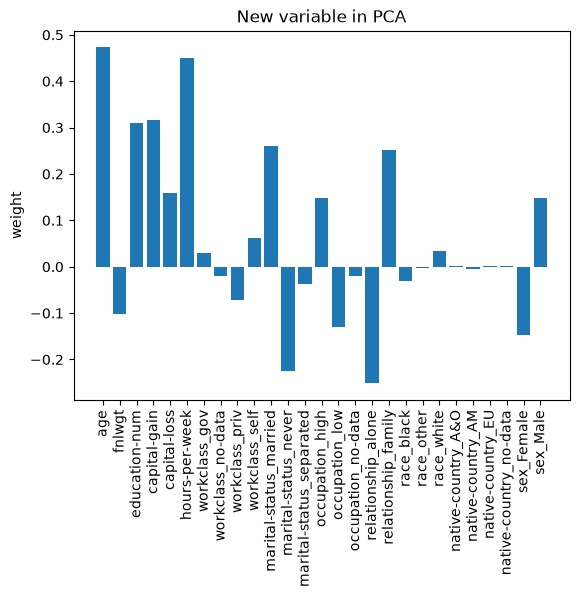

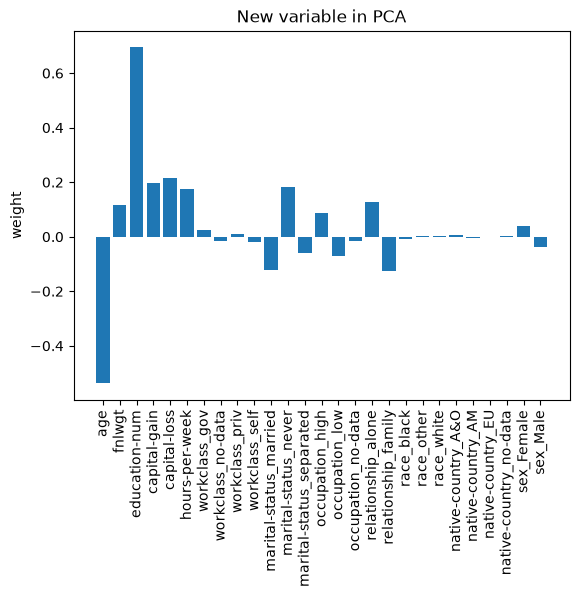

,PC1,PC2
age,0.472751,-0.538168
fnlwgt,-0.102681,0.114981
education-num,0.310835,0.694118
capital-gain,0.315959,0.195897
capital-loss,0.158272,0.213736
hours-per-week,0.450788,0.174035
workclass_gov,0.029041,0.025557
workclass_no-data,-0.019514,-0.014842
workclass_priv,-0.071133,0.009493
workclass_self,0.061606,-0.020209


age                         0.472751
hours-per-week              0.450788
capital-gain                0.315959
education-num               0.310835
marital-status_married      0.260972
relationship_family         0.251763
relationship_alone          0.251763
marital-status_never        0.223868
capital-loss                0.158272
occupation_high             0.148579
sex_Male                    0.147473
sex_Female                  0.147473
occupation_low              0.129066
fnlwgt                      0.102681
workclass_priv              0.071133
workclass_self              0.061606
marital-status_separated    0.037104
race_white                  0.033923
race_black                  0.031605
workclass_gov               0.029041
workclass_no-data           0.019514
occupation_no-data          0.019514
native-country_AM           0.005484
native-country_A&O          0.002402
race_other                  0.002317
native-country_EU           0.001749
native-country_no-data      0.001334
N

education-num               0.694118
age                         0.538168
capital-loss                0.213736
capital-gain                0.195897
marital-status_never        0.181770
hours-per-week              0.174035
relationship_alone          0.127046
relationship_family         0.127046
marital-status_married      0.121270
fnlwgt                      0.114981
occupation_high             0.086325
occupation_low              0.071483
marital-status_separated    0.060500
sex_Female                  0.038877
sex_Male                    0.038877
workclass_gov               0.025557
workclass_self              0.020209
occupation_no-data          0.014842
workclass_no-data           0.014842
workclass_priv              0.009493
race_black                  0.007300
native-country_AM           0.005515
native-country_A&O          0.004972
race_other                  0.004072
race_white                  0.003228
native-country_no-data      0.002163
native-country_EU           0.001620
N

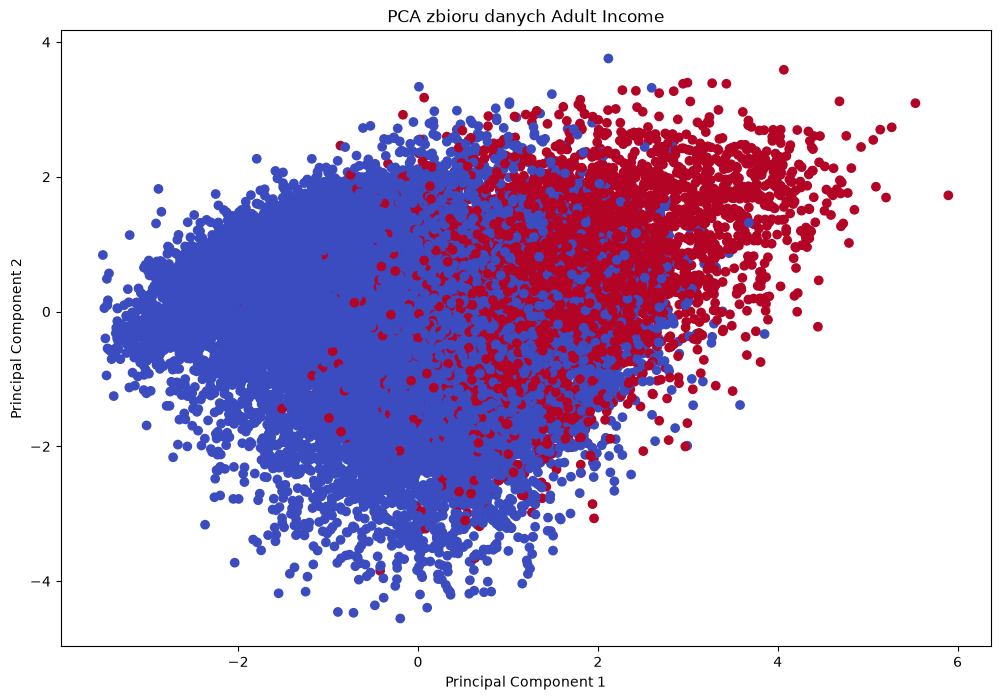

In [ ]:
pca = PCA(n_components=2, random_state=67)
income_pca = pd.DataFrame(pca.fit_transform(df.drop('target', axis=1)), columns=['principal component 1', 'principal component 2'])
display(income_pca.head(10))

for component in pca.components_:
  plt.bar(df.drop('target', axis=1).columns, component)
  plt.xticks(rotation=90)
  plt.title('New variable in PCA')
  plt.ylabel('weight')
  plt.show()

loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1','PC2'],
    index=df.drop('target', axis=1).columns
)
display(loadings)
display(loadings["PC1"].abs().sort_values(ascending=False))
display(loadings["PC2"].abs().sort_values(ascending=False))
# zgodnie z oczekiwaniami największy wpływ mają: age, education-num i hours-per-week

plt.figure(figsize=(12, 8))
plt.scatter(income_pca['principal component 1'], income_pca['principal component 2'], c=df['target'], cmap='coolwarm', )
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA zbioru danych Adult Income')
plt.show() # wyraźna separacja!

## Przygotowanie danych testowych

In [168]:
testset = pd.DataFrame(scaler.transform(test_data.select_dtypes(include=np.number)), 
                  columns=test_data.select_dtypes(include=np.number).columns,
                  index=test_data.index)
for col in cat_cols:
    if col != 'sex':
        testset[col] = test_data[col].map(categorizer)
testset = testset.assign(sex = test_data['sex'], target = test_data['target'].eq('>50K'))
testset = testset.dropna()
non_encoded = pd.DataFrame(pd.concat([testset[cat_cols],test_data.select_dtypes(include=np.number),test_data['target'].eq('>50K')], axis=1))
non_encoded = non_encoded.dropna()
encoded_data = encoder.transform(testset[cat_cols])
encoded_testset = pd.DataFrame(
    encoded_data,
    columns=encoder.get_feature_names_out(cat_cols),
    index=testset.index
)
testset = pd.DataFrame(pd.concat([testset.drop(columns=cat_cols), encoded_testset], axis=1))
print(testset.shape[0], non_encoded.shape[0])

9638 9638


## Klasyfikacja

### Trenowanie modelu

In [137]:
param_grid = {
    'n_neighbors' : [21,23,25,27,29],
    'metric' : ['euclidean','manhattan','minkowski'],
    'weights' : ['uniform','distance']
}
grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='f1_macro'
)
grid_search.fit(df.drop('target', axis=1), df['target'])

print(f"Best params: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.3f}")

Best params: {'metric': 'euclidean', 'n_neighbors': 27, 'weights': 'uniform'}
Best CV score: 0.773


### Testowanie modelu

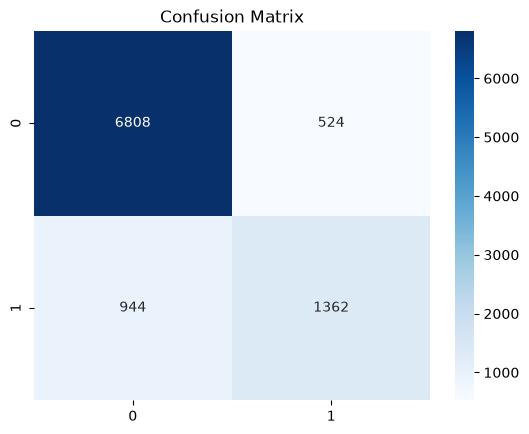

Accuracy: 0.848, Precision: 0.722
Recall: 0.591, F1: 0.650, AUC: 0.898


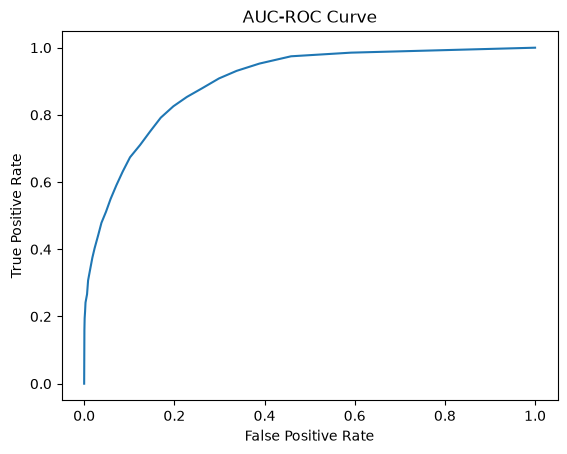

In [146]:
best_model = grid_search.best_estimator_
pred = pd.Series(best_model.predict(testset.drop('target', axis=1)), index=testset.index)

acc = accuracy_score(testset['target'], pred)
precision = precision_score(testset['target'], pred, average='binary')
recall = recall_score(testset['target'], pred, average='binary')
f1 = f1_score(testset['target'], pred, average='binary')

cm = confusion_matrix(testset['target'], pred)
sbn.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title('Confusion Matrix')
plt.show()

proba = best_model.predict_proba(testset.drop('target', axis=1))[:,1]
auc = roc_auc_score(testset['target'], proba)
print(f"Accuracy: {acc:.3f}, Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}, F1: {f1:.3f}, AUC: {auc:.3f}")

fpr, tpr, thresholds = roc_curve(testset['target'], proba)
plt.plot(fpr, tpr)
plt.title('AUC-ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

## Analiza błędów

,workclass,marital-status,occupation,relationship,race,native-country,sex,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,target
28863,priv,married,low,family,white,AM,Male,41,271753,13,0,0,40,False
16557,priv,married,low,family,white,AM,Female,31,240283,13,0,0,40,True
659,priv,married,high,family,white,AM,Male,43,174524,9,0,0,40,True
25383,gov,never,high,alone,black,AM,Female,36,174640,11,0,0,60,True
3627,priv,married,high,family,other,A&O,Male,36,120760,14,0,0,40,False
41952,priv,married,low,family,white,AM,Male,41,145175,10,3103,0,40,True
4417,self,married,low,family,white,AM,Male,40,207578,9,0,0,50,True
1324,priv,married,low,family,white,AM,Male,39,83893,9,0,0,40,True
15579,no-data,married,no-data,family,white,AM,Male,61,116230,13,0,0,40,True
35937,gov,married,high,family,white,AM,Male,46,60751,11,0,0,40,True


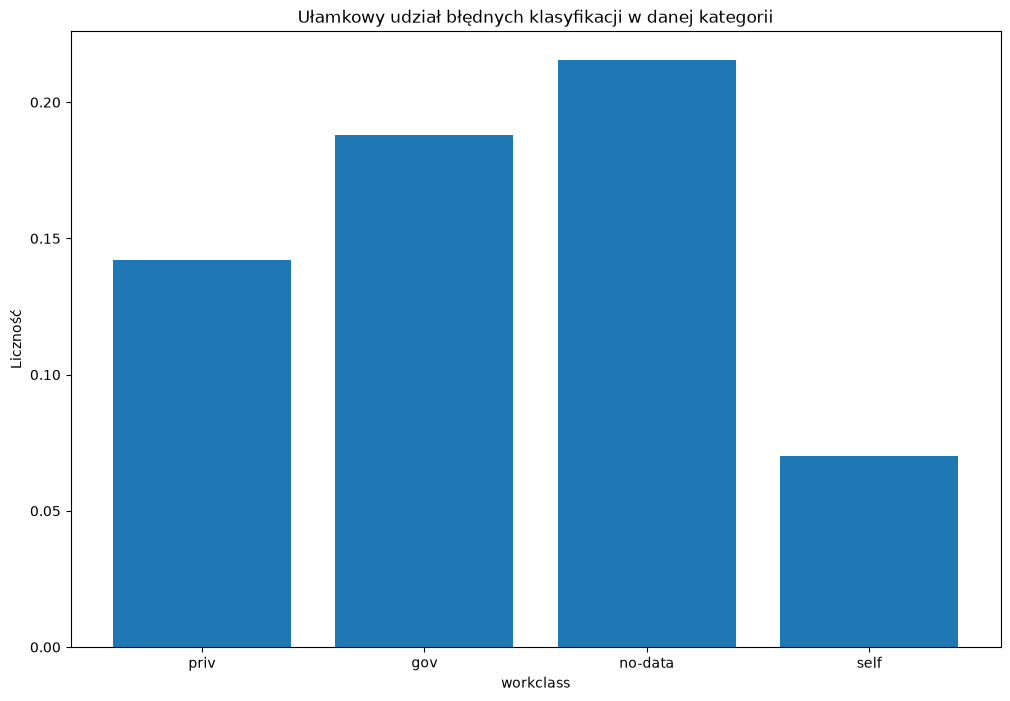

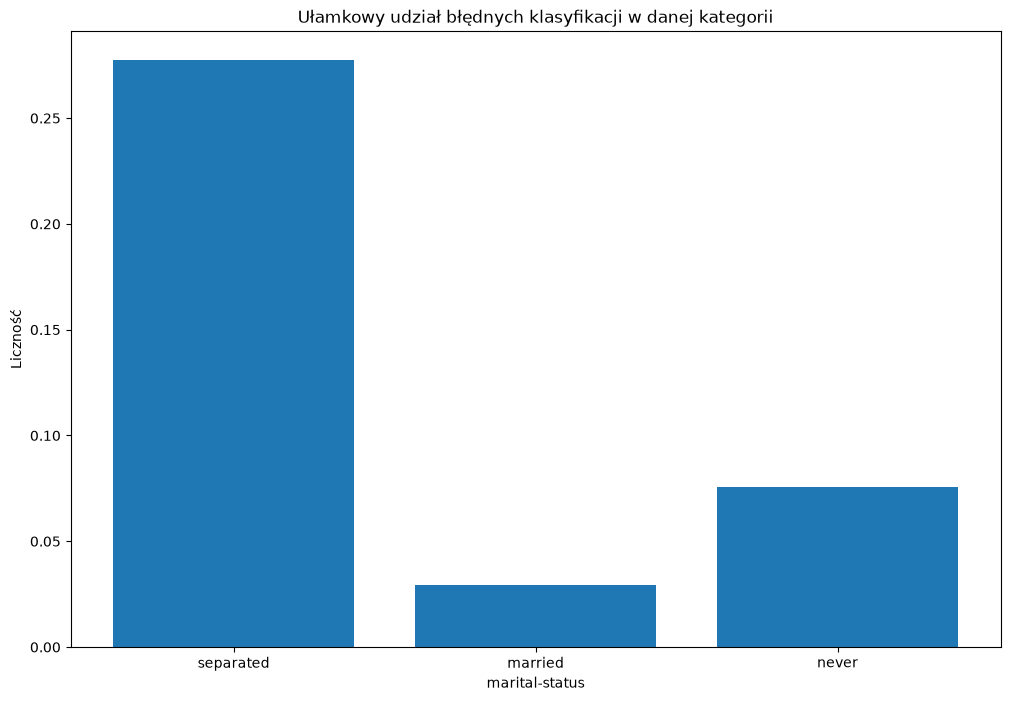

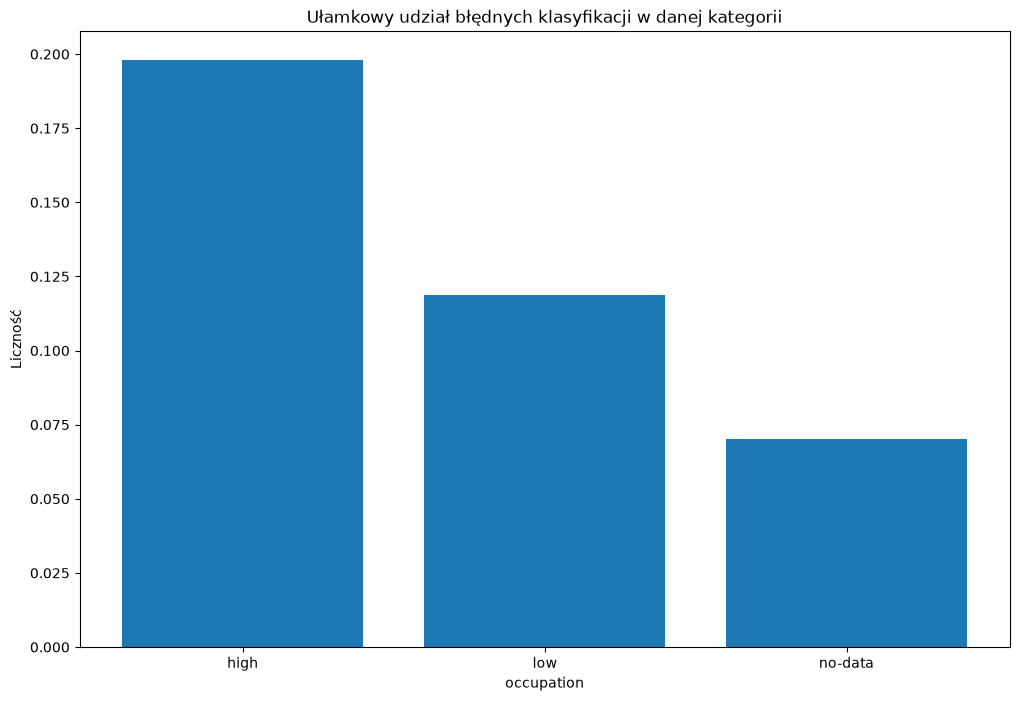

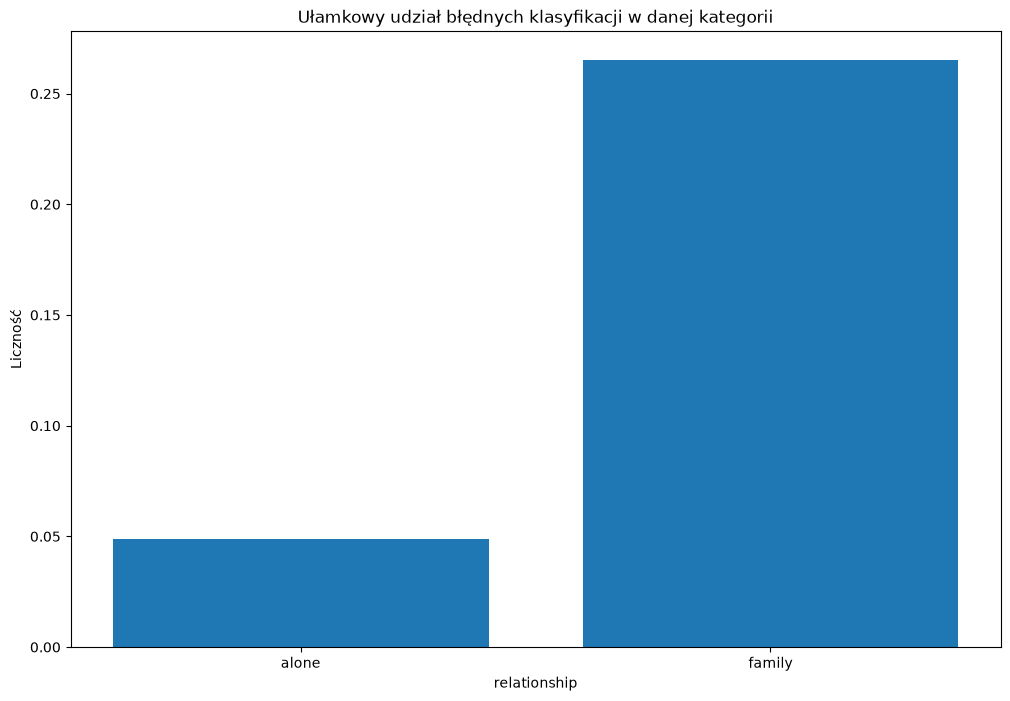

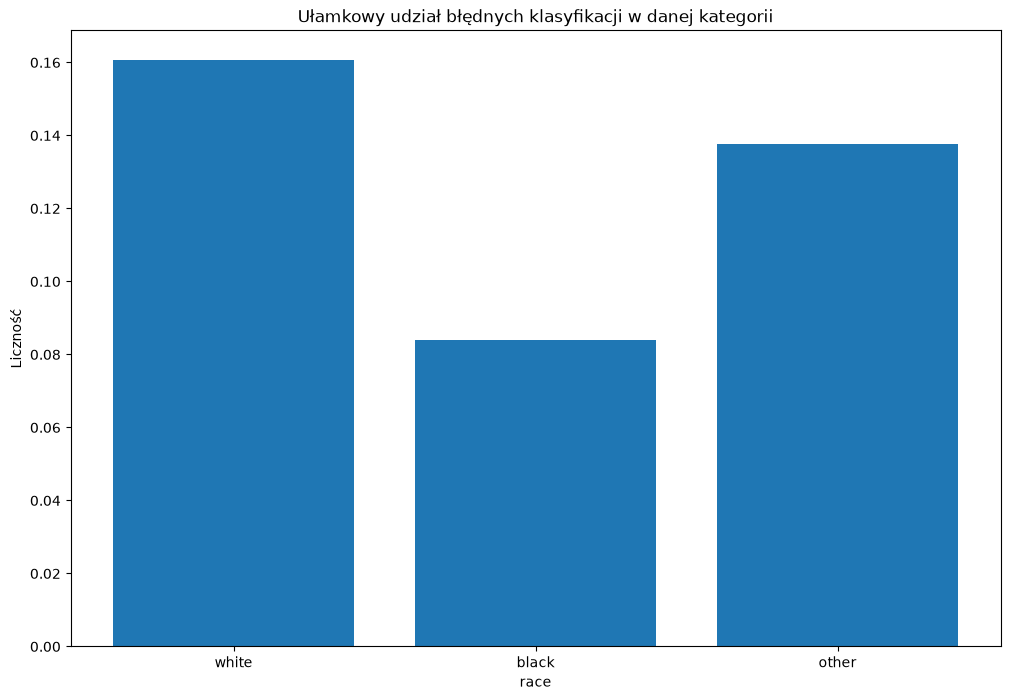

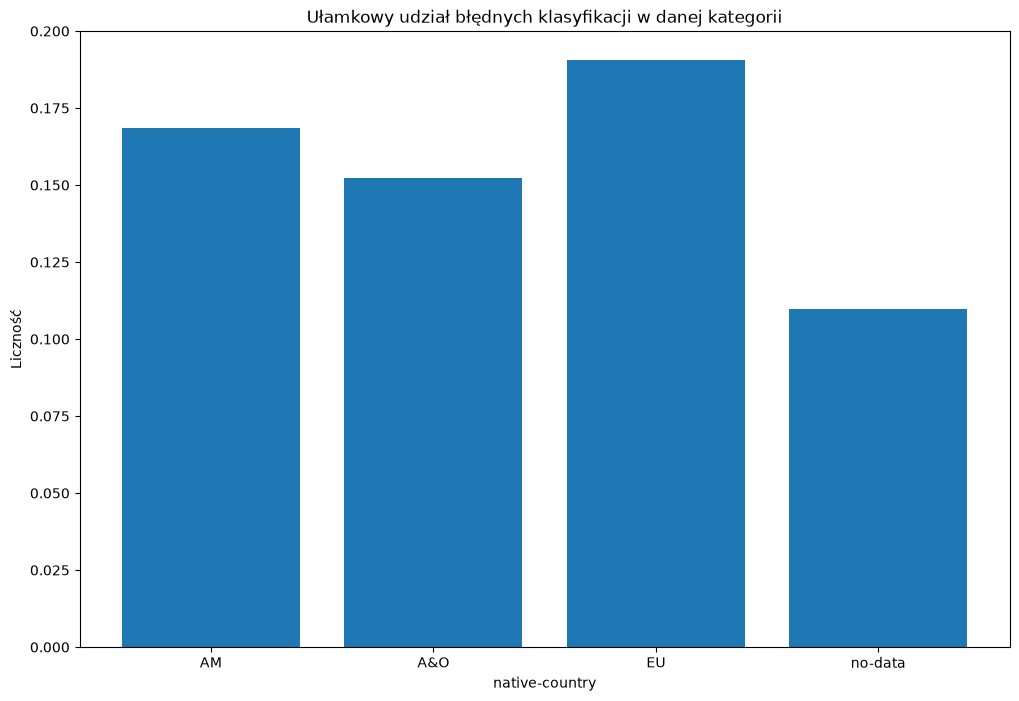

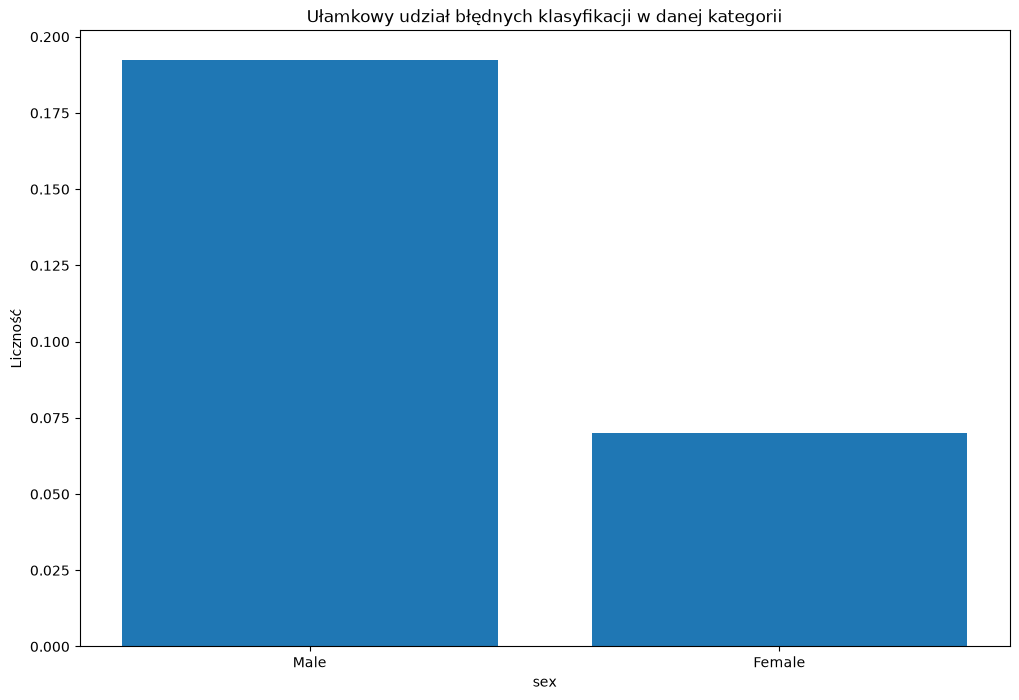

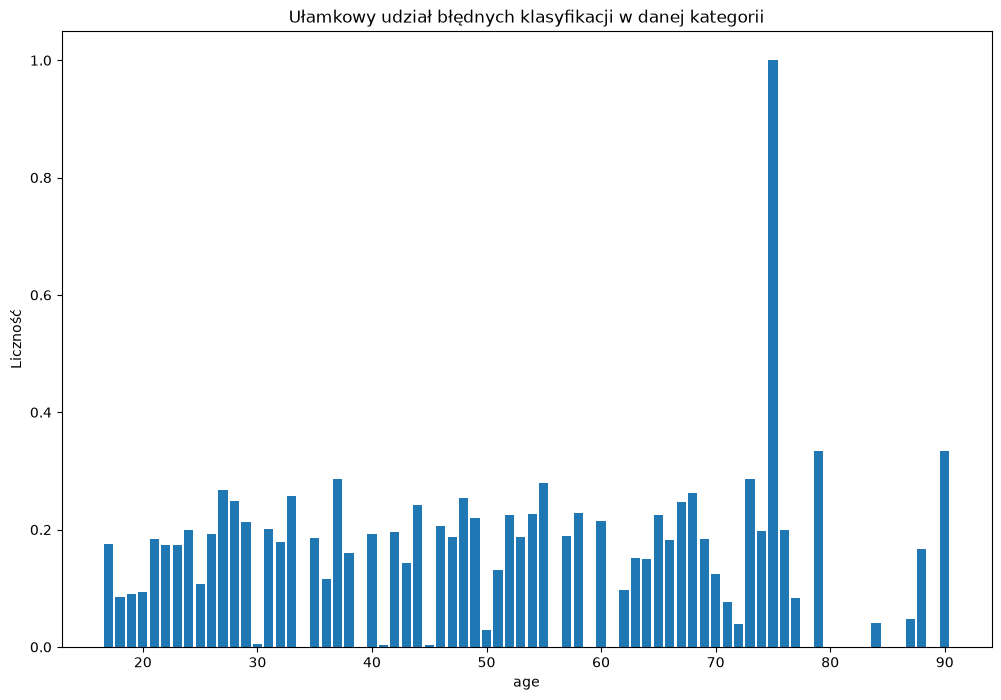

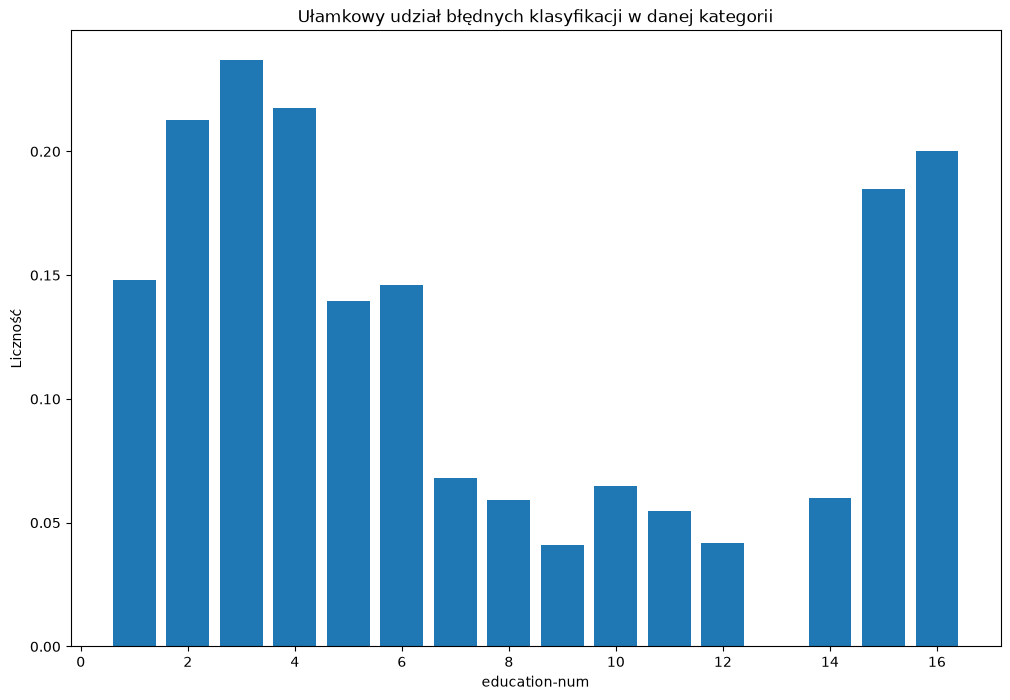

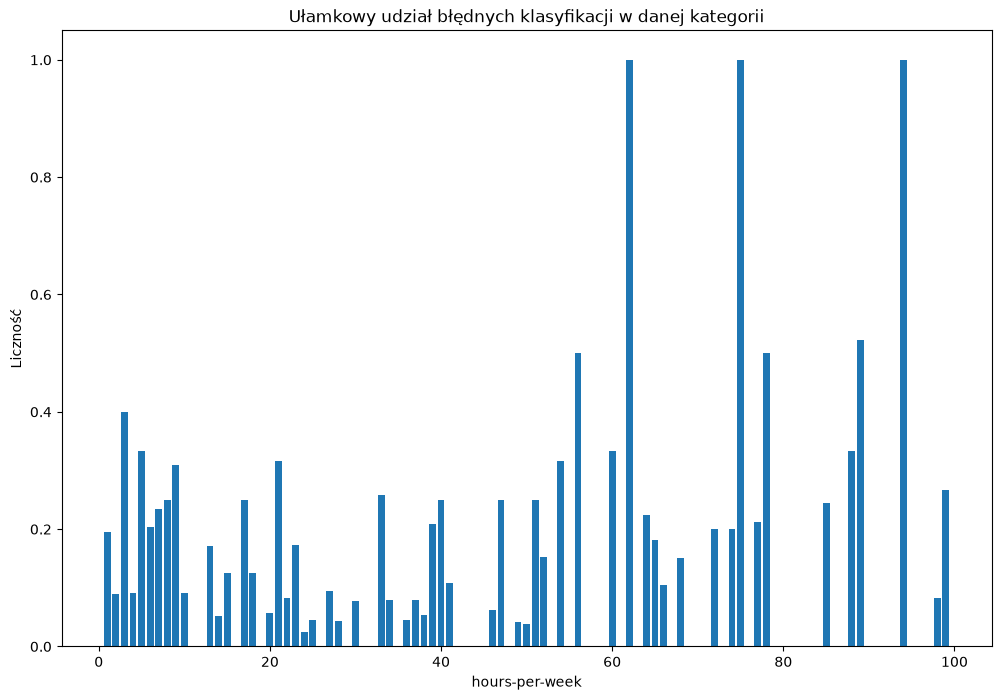

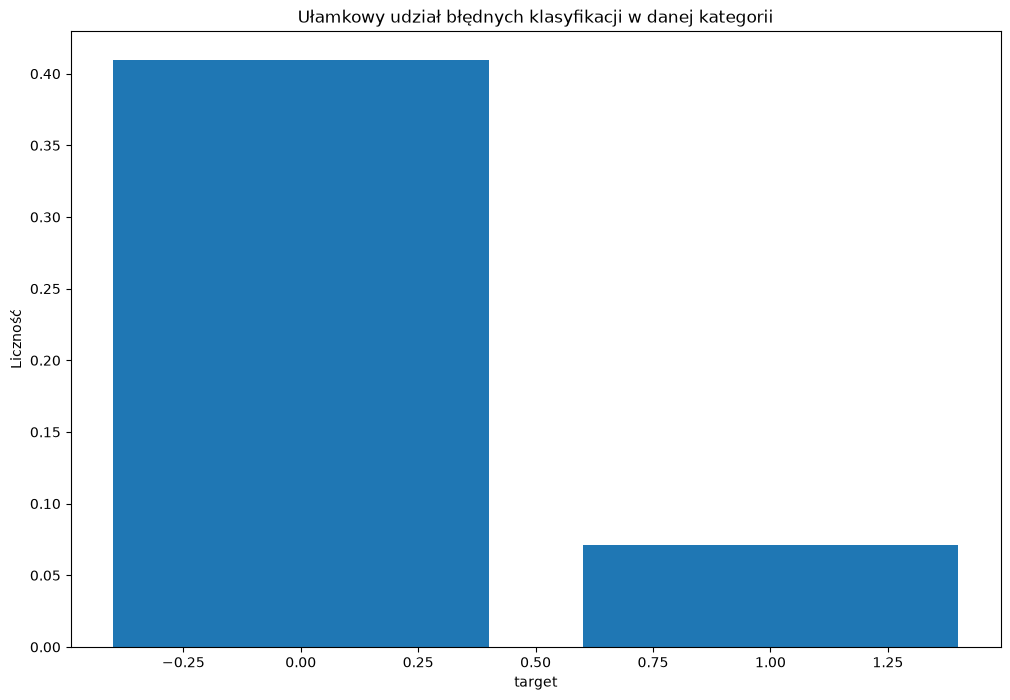

In [175]:
wrong = non_encoded[pred != non_encoded["target"]]
display(wrong.head(10))

for col in wrong.columns:
    if col in ['fnlwgt','capital-gain','capital-loss']:
        continue
    plt.figure(figsize=(12,8))
    plt.bar(non_encoded[col].drop_duplicates(), wrong[col].value_counts().divide(non_encoded[col].value_counts(), fill_value=0))
    plt.title('Ułamkowy udział błędnych klasyfikacji w danej kategorii')
    plt.xlabel(col)
    plt.ylabel('Liczność')
    plt.show()

## Podsumowanie

Porównajmy wyniki z tymi na oficjalnej stronie zbioru danych: https://archive.ics.uci.edu/dataset/2/adult

Mamy bardzo dobre Accuracy, wyraźnie przebijamy Support Vector Classification, Neural Network Classification i Logistic Regression.

Słabą stroną modelu jest Precision, gdzie przegrywa z wszystkimi innymi metodami.

Najbardziej dumny jestem z dobrego PCA.